Custom inverse fit parameters: a=-1742.8794, b=1.4677, c=1241.4010


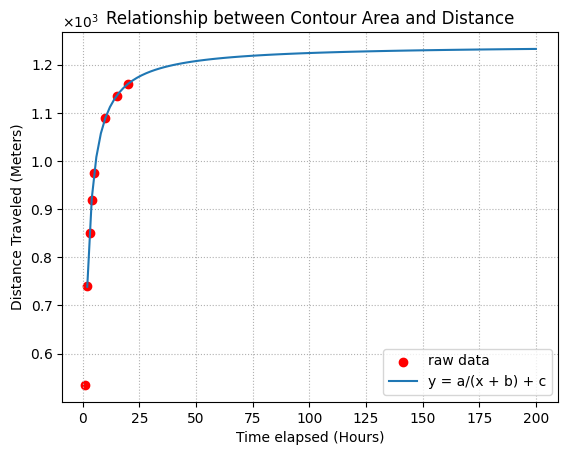

Predicted total distance at 3.4 hours: 0.883 km
Time to travel 650 meters: 1.48 hours


In [39]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

x_data = np.array([1, 2, 3, 4, 5, 10, 15, 20])
y_data = np.array([535, 740, 850, 920, 975, 1090, 1135, 1160])

x = np.linspace(2, 200, 100)

# Custom inverse fit: y = a/(x + b) + c
def custom_inv_function(x, a, b, c):
    return a / (x + b) + c
params_custom, _ = curve_fit(custom_inv_function, x_data, y_data)
y_custom = custom_inv_function(x, *params_custom)

print(f"Custom inverse fit parameters: a={params_custom[0]:.4f}, b={params_custom[1]:.4f}, c={params_custom[2]:.4f}")

plt.scatter(x_data, y_data, label="raw data", color="red")
plt.plot(x, y_custom, label="y = a/(x + b) + c")

plt.legend()
plt.grid(True, linestyle=":")
plt.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

plt.title("Relationship between Contour Area and Distance")
plt.xlabel("Time elapsed (Hours)")
plt.ylabel("Distance Traveled (Meters)")
plt.show()

# Modify anything below to calculate different parameters

# --- Regression and Prediction ---
# Easily adjust the time value below
time_elapsed = 3.4  # hours
predicted_distance_m = custom_inv_function(time_elapsed, *params_custom)
predicted_distance_km = predicted_distance_m / 1000
print(f"Predicted total distance at {time_elapsed} hours: {predicted_distance_km:.3f} km")

# --- Find time for a given distance ---
# Easily adjust the target distance below
target_distance_m = 650
from scipy.optimize import fsolve
def find_time_for_distance(target_distance, params):
    # Solve custom_inv_function(time, *params) = target_distance
    func = lambda t: custom_inv_function(t, *params) - target_distance
    # Initial guess: use mean of x_data
    time_solution = fsolve(func, np.mean(x_data))[0]
    return time_solution

time_for_650m = find_time_for_distance(target_distance_m, params_custom)
print(f"Time to travel {target_distance_m} meters: {time_for_650m:.2f} hours")


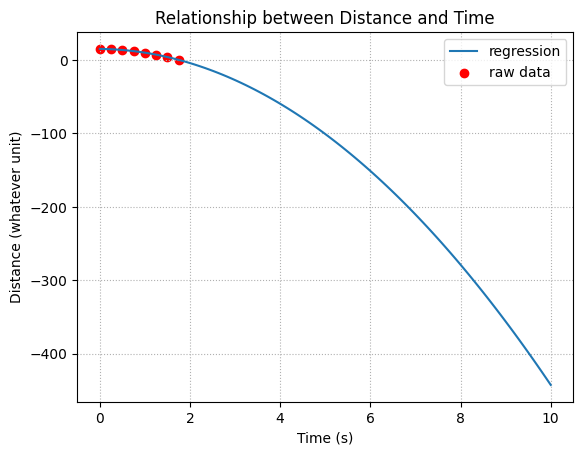

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# [FUNCTION] Predicts distance on a curve
def curve_predict():
    # (x, y) = (time, distance in cm)
    data = [(0, 15),(0.25, 14.6),(0.5, 13.5),(0.75, 12.2),(1.0, 10),(1.25, 7.1),(1.5, 3.7),(1.75, 0.3)]
    data_t = np.transpose(data)

    b_val = np.polyfit(data_t[0], data_t[1], 2) # 2 is the degree of the polynomial
    x = np.linspace(0, 10, 100)
    y = b_val[0]*x**2+b_val[1]*x+b_val[2]
    plt.plot(x, y, label="regression")
    plt.scatter(data_t[0], data_t[1], label="raw data", color="red")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.title("Relationship between Distance and Time")
    plt.xlabel("Time (s)")
    plt.ylabel("Distance (whatever unit)")
    plt.show()

    # Modify the below for different unknowns
    # x = 0.4
    # y = b_val[0]*x**2+b_val[1]*x+b_val[2]
    # a = b_val[0]
    # b = b_val[1]
    # c = b_val[2]
    # print(a)

def main():
    curve_predict()


if __name__ == "__main__":
    main()